In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Load the dataset
borrower_profile = pd.read_csv("C:\\Users\\USER\\Downloads\\loan-default-risk-analysis-vjfdl\\borrower_profiles.csv")
loan_data = pd.read_csv("C:\\Users\\USER\\Downloads\\loan-default-risk-analysis-vjfdl\\loan_applications.csv")

In [3]:
#preview the borrower profile dataset

borrower_profile.head()


,borrower_id,age,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,dependents,existing_monthly_debt
0,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,892
1,BRW-0002,24,CO,High School,Full-Time,4,40188,543,Own,2,869
2,BRW-0003,50,NC,Bachelor,Contract,22,41014,611,Mortgage,0,1806
3,BRW-0004,43,TX,High School,Full-Time,19,35036,701,Mortgage,2,928
4,BRW-0005,46,NY,High School,Full-Time,18,44528,715,Own,0,608


In [4]:
#preview the loan application dataset
loan_data.head()

,loan_id,borrower_id,application_date,loan_purpose,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,loan_status,days_delinquent,defaulted
0,LN-00001,BRW-0001,2024-01-08,Vacation,16100.0,36,13.05,542.86,55.5,Paid Off,0,0
1,LN-00002,BRW-0001,2024-08-13,Major Purchase,5600.0,48,14.21,153.62,40.4,Default,138,1
2,LN-00003,BRW-0002,2025-06-28,Moving,44700.0,36,12.37,1492.59,70.5,Paid Off,0,0
3,LN-00004,BRW-0003,2025-05-18,Auto Loan,9200.0,48,11.18,238.58,59.8,Default,34,1
4,LN-00005,BRW-0004,2025-03-24,Moving,11200.0,36,9.66,359.61,44.1,Current,0,0


In [5]:
loan_data.describe()

,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,days_delinquent,defaulted
count,601.000000,601.000000,601.000000,601.000000,601.000000,601.000000,601.000000
mean,22148.252912,36.539101,10.641331,948.337654,49.680699,27.036606,0.242928
std,13215.261422,16.898192,2.251153,864.959543,24.113652,47.802845,0.429209
min,2000.000000,12.000000,5.860000,44.140000,7.600000,0.000000,0.000000
25%,10900.000000,24.000000,8.940000,359.860000,32.200000,0.000000,0.000000
50%,20400.000000,36.000000,10.540000,684.870000,48.100000,0.000000,0.000000
75%,32700.000000,48.000000,12.330000,1165.200000,62.400000,30.000000,0.000000
max,49800.000000,60.000000,15.860000,4262.690000,177.400000,180.000000,1.000000


In [6]:
borrower_profile.describe()

,age,years_employed,annual_income,credit_score,dependents,existing_monthly_debt
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,44.986000,10.854000,64471.484000,704.952000,1.356000,1585.166000
std,13.539736,9.301706,28959.837645,97.339157,1.252358,1089.979915
min,22.000000,0.000000,12549.000000,528.000000,0.000000,124.000000
25%,33.000000,3.000000,42968.250000,617.750000,0.000000,788.750000
50%,45.000000,8.000000,59282.500000,708.000000,1.000000,1312.000000
75%,57.000000,17.000000,79780.500000,794.250000,2.000000,2131.750000
max,68.000000,35.000000,157047.000000,850.000000,4.000000,6130.000000


In [7]:
borrower_profile.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   borrower_id            500 non-null    object
 1   age                    500 non-null    int64 
 2   state                  500 non-null    object
 3   education_level        500 non-null    object
 4   employment_status      500 non-null    object
 5   years_employed         500 non-null    int64 
 6   annual_income          500 non-null    int64 
 7   credit_score           500 non-null    int64 
 8   home_ownership         500 non-null    object
 9   dependents             500 non-null    int64 
 10  existing_monthly_debt  500 non-null    int64 
dtypes: int64(6), object(5)
memory usage: 43.1+ KB


In [8]:
# Merge the datasets on 'borrower_id'

df = pd.merge(loan_data, borrower_profile, on='borrower_id', how='inner')
print(df.head())

    loan_id borrower_id application_date    loan_purpose  loan_amount  \
0  LN-00001    BRW-0001       2024-01-08        Vacation      16100.0   
1  LN-00002    BRW-0001       2024-08-13  Major Purchase       5600.0   
2  LN-00003    BRW-0002       2025-06-28          Moving      44700.0   
3  LN-00004    BRW-0003       2025-05-18       Auto Loan       9200.0   
4  LN-00005    BRW-0004       2025-03-24          Moving      11200.0   

   term_months  interest_rate  monthly_payment  dti_ratio loan_status  ...  \
0           36          13.05           542.86       55.5    Paid Off  ...   
1           48          14.21           153.62       40.4     Default  ...   
2           36          12.37          1492.59       70.5    Paid Off  ...   
3           48          11.18           238.58       59.8     Default  ...   
4           36           9.66           359.61       44.1     Current  ...   

   age  state  education_level employment_status years_employed annual_income  \
0   62     

## Segment Analysis 1: Default rate by credit score buckets


In [9]:

#Finding the minimum and maximum credit scores so that I can create appropriate buckets for credit score categorization

min_credit_score = df['credit_score'].min()
max_credit_score = df['credit_score'].max()
print("Minimum Credit Score:", min_credit_score)    
print("Maximum Credit Score:", max_credit_score)


'''Credit score buckets can be created based on the following ranges:
    
- Poor: 500-599
- Fair: 600-699
- Good: 700-799
- Very Good: 800-899
'''

df['credit_score_buckets'] = pd.cut(
    df['credit_score'],
    bins=[500, 599, 699, 799, 899],
    labels=['500-599', '600-699', '700-799', '800-899'],
    right=False
)


#Creating a default flag based on the 'loan_status' column. If the loan status is 'Default', the default flag will be set to 1, otherwise it will be set to 0.

df['defaulted'] = df['loan_status'].apply(lambda x: 1 if x == 'Default' else 0)

#Calculating the default rate for each credit score bucket

default_rate_by_bucket = df.groupby('credit_score_buckets', observed = True)['defaulted'].mean().reset_index()
default_rate_by_bucket['default_rate'] = default_rate_by_bucket['defaulted'] * 100
print(default_rate_by_bucket)


Minimum Credit Score: 528
Maximum Credit Score: 850
  credit_score_buckets  defaulted  default_rate
0              500-599   0.495652     49.565217
1              600-699   0.284024     28.402367
2              700-799   0.111111     11.111111
3              800-899   0.150685     15.068493


## Segment Analysis 2: Default rate by Debt to Income Ratio (DTI) buckets

In [10]:
#Finding the minimum and maximum credit scores so that I can create appropriate buckets for credit score categorization

min_dti = df['dti_ratio'].min()
max_dti = df['dti_ratio'].max()

print("Minimum DTI:", min_dti)
print("Maximum DTI:", max_dti)

'''DTI ratio buckets can be created based on the following ranges:
- Very Low: 0-30
- Low: 30-60
- Moderate: 60-90
- High: 90-120
- Very High: 120+
'''

df['dti_buckets'] = pd.cut(
    df['dti_ratio'],
    bins=[0, 30, 60, 90, 120, np.inf],
    labels=['0-29', '30-59', '60-89', '90-119', '120+'],
    right=False
)

default_rate_by_dti_bucket = df.groupby('dti_buckets', observed = True)['defaulted'].mean().reset_index()
default_rate_by_dti_bucket['default_rate'] = default_rate_by_dti_bucket['defaulted'] * 100
print(default_rate_by_dti_bucket)


Minimum DTI: 7.6
Maximum DTI: 177.4
  dti_buckets  defaulted  default_rate
0        0-29   0.142857     14.285714
1       30-59   0.217822     21.782178
2       60-89   0.355072     35.507246
3      90-119   0.416667     41.666667
4        120+   0.300000     30.000000


## Segment Analysis 3: Default rate by Employment Status

In [11]:
# Calculation of default rate by employment status

default_rate_by_employment_status = df.groupby('employment_status', observed=True)['defaulted'].mean().reset_index()
default_rate_by_employment_status['default_rate'] = default_rate_by_employment_status['defaulted'] * 100
print(default_rate_by_employment_status)

  employment_status  defaulted  default_rate
0          Contract   0.227273     22.727273
1         Full-Time   0.239344     23.934426
2         Part-Time   0.276923     27.692308
3           Retired   0.233333     23.333333
4     Self-Employed   0.247619     24.761905


## Segment Analysis 4: Default rate by Loan Purpose

In [12]:
#Calculation of default rate by employment status

default_rate_by_loan_purpose =  df.groupby('loan_purpose', observed=True)['defaulted'].mean().reset_index()
default_rate_by_loan_purpose['default_rate'] = default_rate_by_loan_purpose['defaulted'] * 100
print(default_rate_by_loan_purpose)

         loan_purpose  defaulted  default_rate
0           Auto Loan   0.271186     27.118644
1       Business Loan   0.241379     24.137931
2  Debt Consolidation   0.215686     21.568627
3           Education   0.226415     22.641509
4    Home Improvement   0.285714     28.571429
5      Major Purchase   0.220588     22.058824
6    Medical Expenses   0.205882     20.588235
7              Moving   0.214286     21.428571
8            Vacation   0.225806     22.580645
9             Wedding   0.321429     32.142857


# Correlation Analysis

## Correlation Analysis 1: Credit Score vs Default Status

In [13]:
# Calculating the correlation between credit score and default status

correlation_credit_score_default = df['credit_score'].corr(df['defaulted'])
print("Correlation between Credit Score and Default Status:", correlation_credit_score_default)

Correlation between Credit Score and Default Status: -0.286393769082028


## Correlation Analysis 2: Debt to Income Ratio vs Default Status

In [14]:
# Calculating the correlation between DTI Ratio and default status


correlation_dti_default = df['dti_ratio'].corr(df['defaulted'])
print("Correlation between DTI Ratio and Default Status:", correlation_dti_default)

Correlation between DTI Ratio and Default Status: 0.19245414949940812


## Correlation Analysis 3: Income vs Default Status

In [15]:
# Calculating the correlation between Annual Income and default status

correlation_income_default = df['annual_income'].corr(df['defaulted'])
print("Correlation between Annual Income and Default Status:", correlation_income_default)

Correlation between Annual Income and Default Status: -0.08154587510311033


## Correlation Analysis 4: Interest Rate vs Default Status

In [16]:
# Calculating the correlation between Interest Rate and default status
correlation_interest_rate_default = df['interest_rate'].corr(df['defaulted'])
print("Correlation between Interest Rate and Default Status:", correlation_interest_rate_default)


Correlation between Interest Rate and Default Status: 0.19893008328871328


# VISUALIZATIONS

## Visualization 1: Default Rate vs Credit Score Range

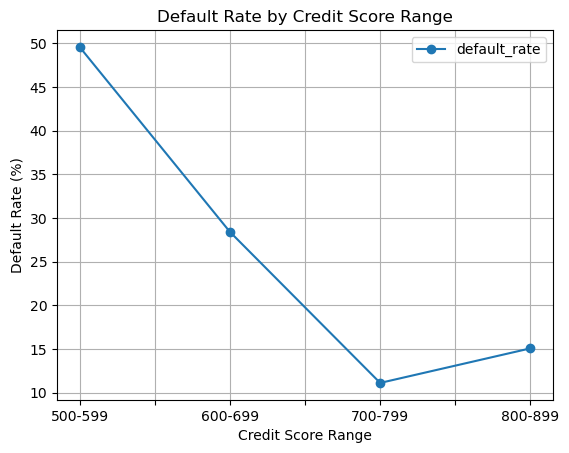

In [17]:
# Line plot to visualize the default rate by credit score buckets

default_rate_by_bucket.plot(
    x='credit_score_buckets',
    y='default_rate',
    kind='line',
    marker='o'
)
plt.title('Default Rate by Credit Score Range')
plt.xlabel('Credit Score Range')
plt.ylabel('Default Rate (%)')
plt.grid(True)
plt.show()

## Visualization 2: Scatter Plot showing the relationship between Default Status vs Debt to Income Ratio

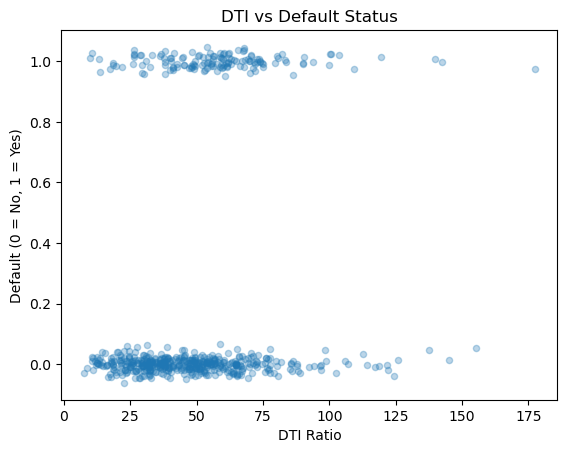

In [18]:
#Scatter plot to visualize the relationship between DTI ratio and default status. Adding jitter to the default status to better visualize the data points.

df['default_jitter'] = df['defaulted'] + np.random.normal(0, 0.02, len(df))

df.plot(
    kind='scatter',
    x='dti_ratio',
    y='default_jitter',
    alpha=0.3
)

plt.title("DTI vs Default Status")
plt.xlabel("DTI Ratio")
plt.ylabel("Default (0 = No, 1 = Yes)")
plt.show()

## Visualization 3: Total Loans by Loan Purpose

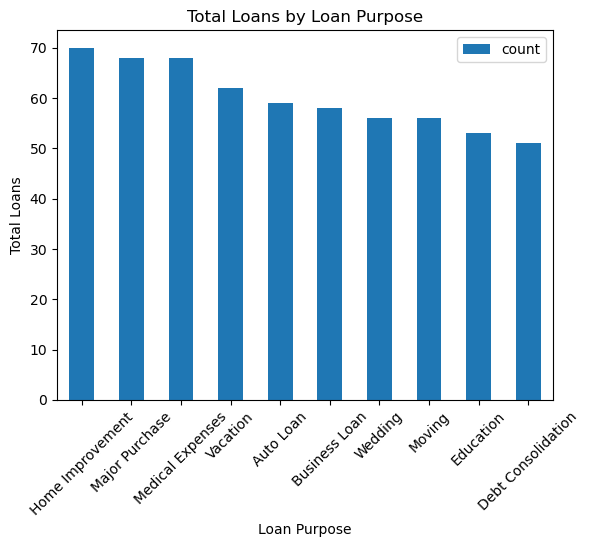

In [19]:
# Bar plot showing the total number of loans by loan purpose. This will help us understand which loan purposes are more common among borrowers.

plot_df = df['loan_purpose'].value_counts().reset_index()
plot_df.columns = ['loan_purpose', 'count']

plot_df.plot(
    kind='bar',
    x='loan_purpose',
    y='count',
    title='Total Loans by Loan Purpose'
)
plt.xlabel('Loan Purpose')
plt.ylabel('Total Loans')
plt.xticks(rotation=45)     
plt.show()

## Visualization 4: Cross-Segment Analysis between Credit Score x Debt to Income Ratio

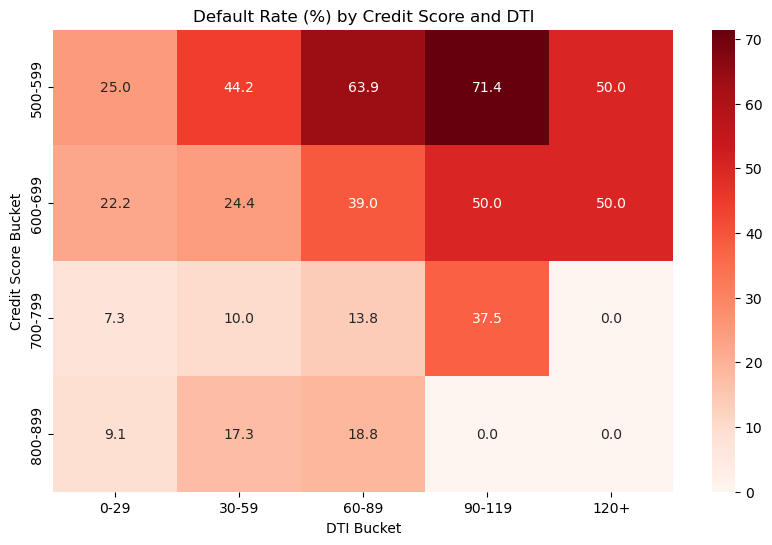

In [20]:
# Pivot table showing the relationship between credit score buckets, DTI buckets, and default rates. This will then be used to create a heatmap to visualize the relationship between credit score, DTI, and default rates. 
# This answers whether borrowers with lower credit scores and higher DTI ratios are more likely to default on their loans.

pivot_table = pd.pivot_table(
    df,
    values='defaulted',
    index='credit_score_buckets',
    columns='dti_buckets',
    aggfunc='mean',
    observed=True
) * 100

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot_table,
    annot=True,
    fmt='.1f',
    cmap='Reds'
)

plt.title('Default Rate (%) by Credit Score and DTI')
plt.xlabel('DTI Bucket')
plt.ylabel('Credit Score Bucket')

plt.show()

## Visualization 5: Default Rate vs Loan Amount 

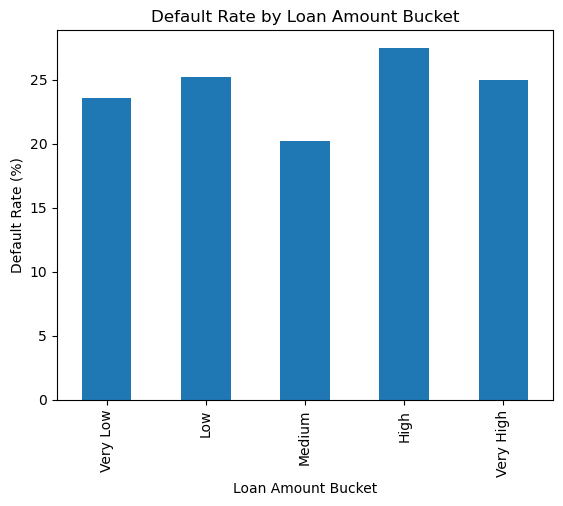

In [21]:
# Creation of loan amount buckets to analyze the relationship between loan amount and default rates. 
df['loan_amount_bucket'] = pd.qcut(
    df['loan_amount'],
    q=5, #Using quantiles ensures roughly equal numbers of loans per bucket. In this case we are using 5 quantiles to create 5 buckets for loan amounts.
    labels=[
        'Very Low',
        'Low',
        'Medium',
        'High',
        'Very High'
    ]
)

# Calculation of default rates

loan_amount_analysis = (
    df.groupby('loan_amount_bucket', observed=True)['defaulted']
      .mean()
      .mul(100)
      .reset_index(name='default_rate')
)

# Charting the default rates by loan amount buckets

loan_amount_analysis.plot(
    x='loan_amount_bucket',
    y='default_rate',
    kind='bar',
    legend=False
    
)

plt.title('Default Rate by Loan Amount Bucket')
plt.ylabel('Default Rate (%)')
plt.xlabel('Loan Amount Bucket')

plt.show()

## Visualization 6: Interest Rate vs Default Rate

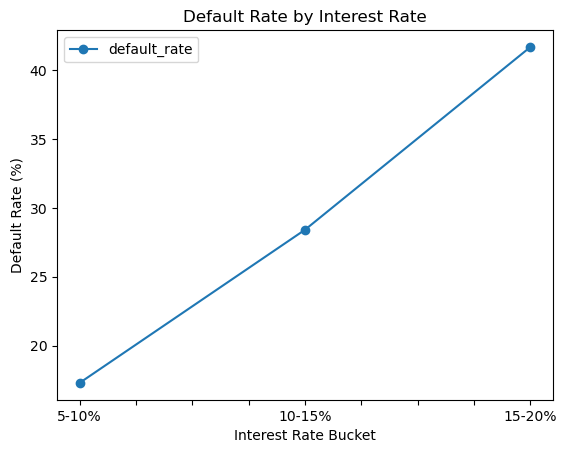

In [22]:
#Creation of interest-rate buckets 

df['interest_bucket'] = pd.cut(
    df['interest_rate'],
    bins=[0,5,10,15,20,25,np.inf],
    labels=[
        '0-5%',
        '5-10%',
        '10-15%',
        '15-20%',
        '20-25%',
        '25%+'
    ]
)

# Calculation of default rates per bucket

interest_rate_analysis = (
    df.groupby('interest_bucket', observed=True)['defaulted']
      .mean()
      .mul(100)
      .reset_index(name='default_rate')
)

#Charting the default rates by interest rate buckets

interest_rate_analysis.plot(
    x='interest_bucket',
    y='default_rate',
    kind='line',
    marker='o'
)

plt.title('Default Rate by Interest Rate')
plt.ylabel('Default Rate (%)')
plt.xlabel('Interest Rate Bucket')

plt.show()

## Highest-Risk Borrower Profile Analysis

In [23]:
#Combining credit score and DTI buckets to create a risk profile. This will help us understand how the combination of these two factors affects the likelihood of default.

risk_profile = (
    df.groupby([
        'credit_score_buckets',
        'dti_buckets'
    ],observed=True)['defaulted']
      .mean()
      .mul(100)
      .reset_index(name='default_rate')
)

#Sorting the risk profile by default rate to identify the highest risk combinations of credit score and DTI.

risk_profile = risk_profile.sort_values(
    by='default_rate',
    ascending=False
)

print(risk_profile.head(10))

   credit_score_buckets dti_buckets  default_rate
3               500-599      90-119     71.428571
2               500-599       60-89     63.888889
8               600-699      90-119     50.000000
4               500-599        120+     50.000000
9               600-699        120+     50.000000
1               500-599       30-59     44.230769
7               600-699       60-89     39.024390
13              700-799      90-119     37.500000
0               500-599        0-29     25.000000
6               600-699       30-59     24.418605


## Loan Term Risk Analysis

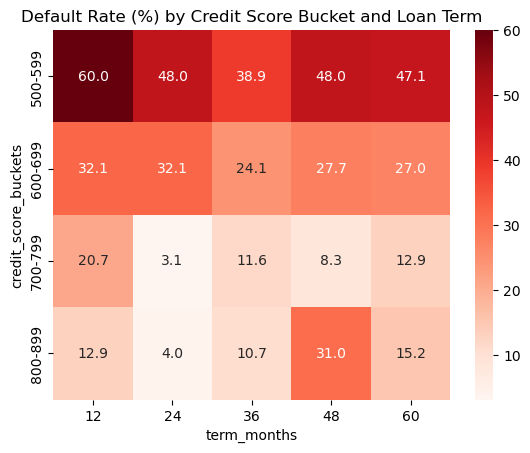

In [ ]:
# Creating a heatmap to visualize the risk profile. This will help us quickly identify which combinations of credit score and DTI are associated with higher default rates.

# Default rate by loan term
default_rate_by_term = (
    df.groupby('term_months', observed=True)['defaulted']
      .mean()
      .mul(100)
      .reset_index(name='default_rate')
      .sort_values('term_months')
)

# Cross-tab: loan term × credit score bucket
term_credit_pivot = pd.pivot_table(
    df,
    values='defaulted',
    index='credit_score_buckets',
    columns='term_months',
    aggfunc='mean',
    observed=True
) * 100

sns.heatmap(term_credit_pivot, annot=True, fmt='.1f', cmap='Reds')
plt.title('Default Rate (%) by Credit Score Bucket and Loan Term')
plt.show()

## Underwriting Recommendations Visualization

In [24]:
# Creation of recommendations based on the analysis. This will help the company make informed decisions about lending practices and risk management.

recommendations = pd.DataFrame({
    'Metric': [
        'Minimum Credit Score',
        'Maximum DTI',
        'Preferred Credit Score'
    ],
    'Threshold': [
        '600',
        '60%',
        '700+'
    ]
})

print(recommendations)


                   Metric Threshold
0    Minimum Credit Score       600
1             Maximum DTI       60%
2  Preferred Credit Score      700+


## Visual Summary

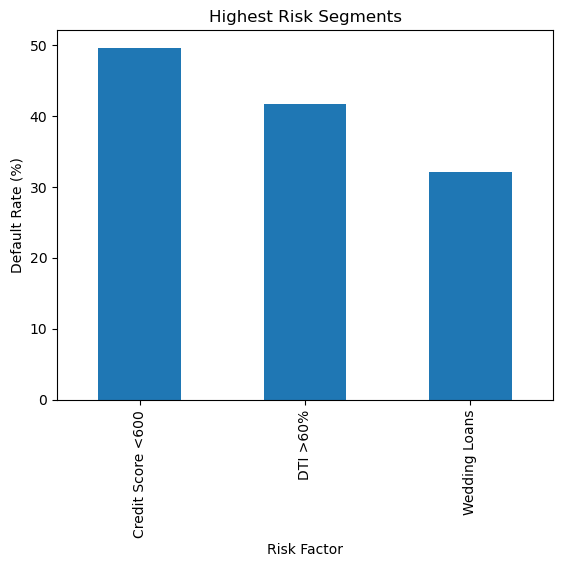

In [25]:
recommendation_data = pd.DataFrame({
    'Risk Factor': [
        'Credit Score <600',
        'DTI >60%',
        'Wedding Loans'
    ],
    'Default Rate': [
        49.6,
        41.7,
        32.1
    ]
})

recommendation_data.plot(
    x='Risk Factor',
    y='Default Rate',
    kind='bar',
    legend=False
)

plt.title('Highest Risk Segments')
plt.ylabel('Default Rate (%)')

plt.show()

## Threshold Approval Simulator

#### This analysis retrospectively applies the recommended underwriting thresholds to the existing 2024–2025 loan book and measures the impact: how many loans would have been declined, what share of actual defaults would have been avoided, and what share of good loans would have been incorrectly rejected.

#### **Question answered:** If we had enforced a minimum credit score of 600 and a DTI cap of 60% from day one, what would the portfolio look like today?

#### **Why it matters:** This is the most direct translation of the analysis into a business case. The VP of Risk needs to know not just *what* the thresholds should be, but *what it costs* to enforce them — in declined revenue and in avoided losses. The simulator makes the trade-off explicit.

In [28]:
df['would_approve'] = (
    (df['credit_score'] >= 600) &
    (df['dti_ratio'] < 60)
)

total_loans       = len(df)
approved          = df['would_approve'].sum()
declined          = total_loans - approved

defaults_caught   = df[~df['would_approve']]['defaulted'].sum()
total_defaults    = df['defaulted'].sum()
good_loans_lost   = (~df['would_approve'] & (df['defaulted'] == 0)).sum()

print(f"Total loans:           {total_loans}")
print(f"Would approve:         {approved}  ({approved/total_loans:.1%})")
print(f"Would decline:         {declined}  ({declined/total_loans:.1%})")
print(f"Defaults prevented:    {defaults_caught} of {total_defaults} ({defaults_caught/total_defaults:.1%})")
print(f"Good loans lost:       {good_loans_lost} ({good_loans_lost/total_loans:.1%})")
print(f"Simulated default rate on approved book: "
      f"{df[df['would_approve']]['defaulted'].mean():.1%}")

Total loans:           601
Would approve:         361  (60.1%)
Would decline:         240  (39.9%)
Defaults prevented:    89 of 146 (61.0%)
Good loans lost:       151 (25.1%)
Simulated default rate on approved book: 15.8%


#### **Interpretation guide:** The output reveals the precision-recall trade-off of the proposed policy. A set of thresholds that catches 80% of defaults while declining only 20% of good loans is a strong result; if good loan rejection is too high, thresholds can be relaxed incrementally and the simulator re-run.